# 4.1 SingleR annotation of the bone marrow microenvironment

Author: Xuezhu Sunny Wang

## Dataset 📊

- scRNA-seq of non-plasma TME cells

## Steps overview 📒

- Use SingleR to annotate the non-plasma cells in bone marrow

In [1]:
library(Seurat)
library(patchwork)
library(speckle)
library(limma)
library(ggplot2)
library(DropletUtils)
library(Matrix)
library(celda)
library(SingleCellExperiment)
library(SingleR)
library(celldex)
library(scCustomize)
set.seed(123)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t






Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollaps

In [2]:
plotCellTypePropscustom<-function (x = NULL, clusters = NULL, sample = NULL) 
{
    if (is.null(x) & is.null(sample) & is.null(clusters)) 
        stop("Please provide either a SingleCellExperiment object or Seurat object with required annotation metadata, or explicitly provide\n          clusters and sample information")
    if ((is.null(clusters) | is.null(sample)) & !is.null(x)) {
        if (is(x, "SingleCellExperiment")) 
            y <- .extractSCE(x)
        if (is(x, "Seurat")) 
            y <- .extractSeurat(x)
        clusters <- y$clusters
        sample <- y$sample
    }
    prop.list <- getTransformedProps(clusters, sample)
    Proportions <- as.vector(t(prop.list$Proportions))
    Samples <- rep(colnames(prop.list$Proportions), nrow(prop.list$Proportions))
    Clusters <- rep(rownames(prop.list$Proportions), each = ncol(prop.list$Proportions))
    plotdf <- data.frame(Samples = Samples, Clusters = Clusters, 
        Proportions = Proportions)
    ggplot(plotdf, aes(x = Samples, y = Proportions, fill = Clusters)) + theme_classic() + scale_fill_manual(values = color_cluster_df[celltypes,]$Color)+
        geom_bar(stat = "identity") + theme(axis.text.x = element_text(size = 12), 
        axis.text.y = element_text(size = 12), axis.title = element_text(size = 14), 
        legend.text = element_text(size = 12), legend.title = element_text(size = 14)) + coord_flip() 
}


In [3]:
sce1<-readRDS(file='./250817-AL-all78umap-singletonly-umap.rds')

In [4]:
sce1

An object of class Seurat 
36601 features across 630111 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, UMAP

In [4]:
clusters_to_keep <- c(60,48,61,50,38,36,37,9,14,26,56,5,65,12,83,55,32,31,42,80,46,57,16,11,4,6,34,64,52,68,64,0,8,41,2,63,53,2,1,3,66,67)
sce1_TME <- subset(sce1, seurat_clusters %in% clusters_to_keep)

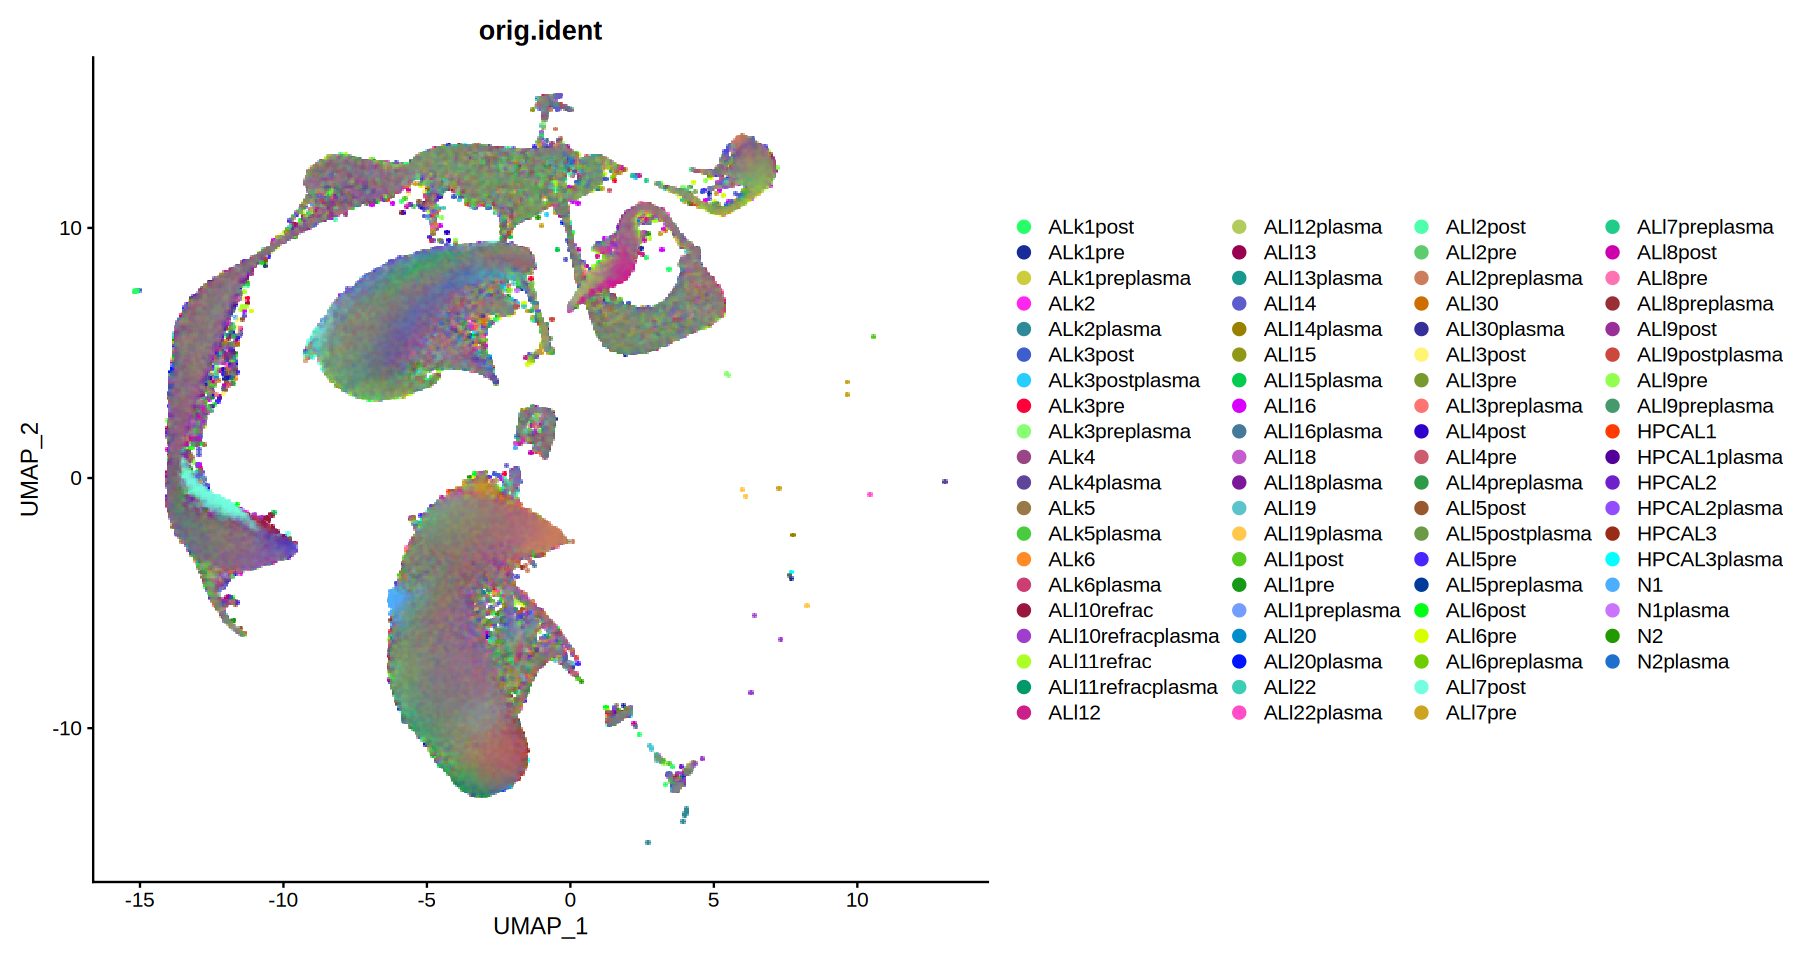

In [5]:
library(scCustomize)
options(repr.plot.height=8,repr.plot.width=15)
DimPlot_scCustom(sce1_TME, pt.size=2,reduction = "UMAP", group.by = c("orig.ident"),label=F) 

In [6]:
# run standard anlaysis workflow
sce1_TME <- NormalizeData(sce1_TME)
sce1_TME <- FindVariableFeatures(sce1_TME)

Normalizing layer: counts

Finding variable features for layer counts



In [7]:
# Step 3: Proceed with PCA and UMAP
sce1_TME <- ScaleData(sce1_TME, features = VariableFeatures(sce1_TME))
sce1_TME <- RunPCA(sce1_TME, features = VariableFeatures(sce1_TME))

Centering and scaling data matrix

Warning message:
“Different features in new layer data than already exists for scale.data”
PC_ 1 
Positive:  IFITM2, CTSS, S100A9, S100A8, RGS2, LST1, NAMPT, FOS, SERPINA1, S100A12 
	   C5AR1, SRGN, SOD2, FCGR3B, CEBPD, FGL2, PTGS2, FCN1, TYMP, VNN2 
	   AQP9, ACSL1, G0S2, AIF1, CXCR2, DUSP6, SMIM25, CMTM2, CXCL8, PSAP 
Negative:  KLF1, CA1, AHSP, PCLAF, CA2, TYMS, NUSAP1, RHAG, CENPF, HBD 
	   BIRC5, HMBS, MYL4, SMIM1, PRDX2, GYPA, MKI67, HEMGN, CCNB2, GYPB 
	   CDK1, PRC1, TOP2A, ANK1, HIST1H1B, DLGAP5, HBM, MYBL2, UBE2T, ZWINT 
PC_ 2 
Positive:  GZMA, CCL5, GZMH, NPM1, EEF1B2, FGFBP2, GNLY, GZMB, KLRD1, TRBC1 
	   IL7R, LDHB, CCL4, KLRB1, HNRNPA1, MIF, PTMA, SPON2, PPIA, CLIC3 
	   PEBP1, CD8B, IFITM1, HSPA8, TRGC2, RPLP0, KLRF1, DUSP2, LTB, HSP90AB1 
Negative:  S100A9, LST1, S100A8, LYZ, CTSS, FCN1, SERPINA1, AIF1, CST3, IFI30 
	   TYMP, PSAP, FGL2, FOS, DUSP6, CD14, CEBPD, NAMPT, VCAN, RGS2 
	   MS4A6A, MPEG1, SOD2, C5AR1, S100A12, CD68, MAFB, CD

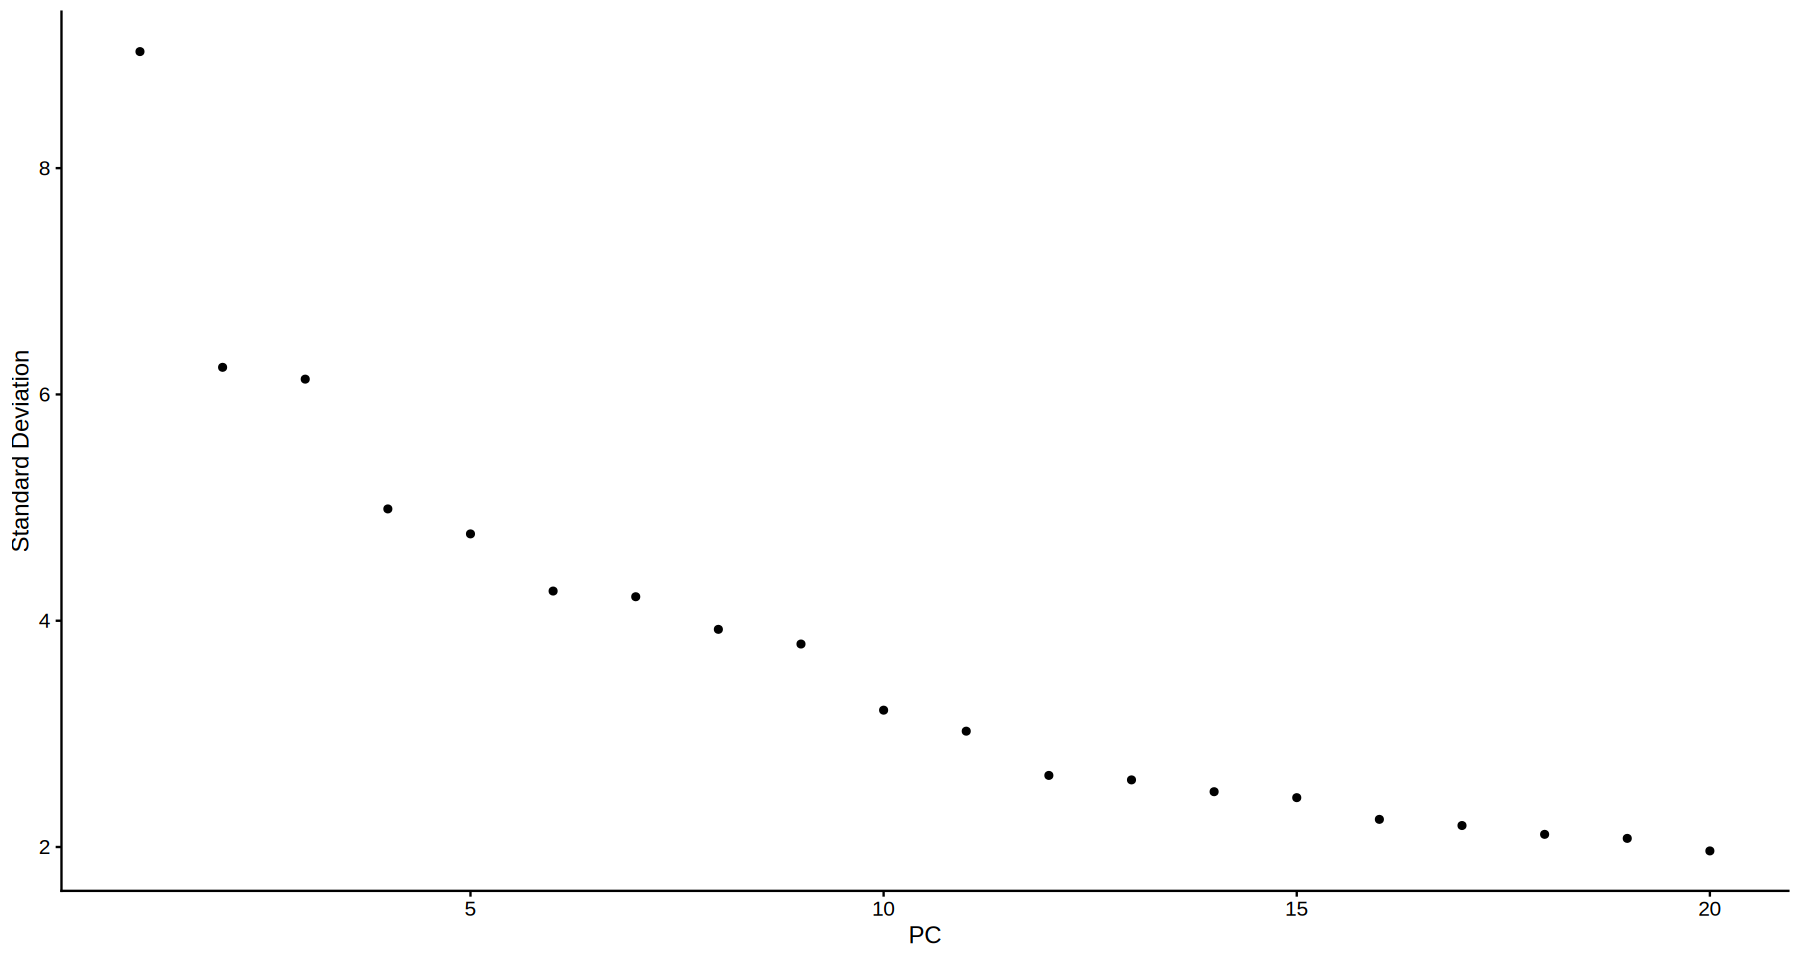

In [8]:
ElbowPlot(sce1_TME)

In [9]:
sce1_TME <- FindNeighbors(sce1_TME, dims = 1:15, reduction = "pca")
sce1_TME <- FindClusters(sce1_TME, resolution =0.1, cluster.name = "seurat_clusters")

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 402447
Number of edges: 9973915

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9810
Number of communities: 18
Elapsed time: 242 seconds


2 singletons identified. 16 final clusters.



In [10]:
sce1_TME <- RunUMAP(sce1_TME, dims = 1:15, reduction = "pca", reduction.name = "UMAP")

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
19:55:59 UMAP embedding parameters a = 0.9922 b = 1.112

19:55:59 Read 402447 rows and found 15 numeric columns

19:55:59 Using Annoy for neighbor search, n_neighbors = 30

19:55:59 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

19:56:35 Writing NN index file to temp file /tmp/RtmpbDwEik/file18532f1b443939

19:56:35 Searching Annoy index using 1 thread, search_k = 3000

20:00:06 Annoy recall = 100%

20:00:08 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbo

In [11]:
sce1_TME

An object of class Seurat 
36601 features across 402447 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, UMAP

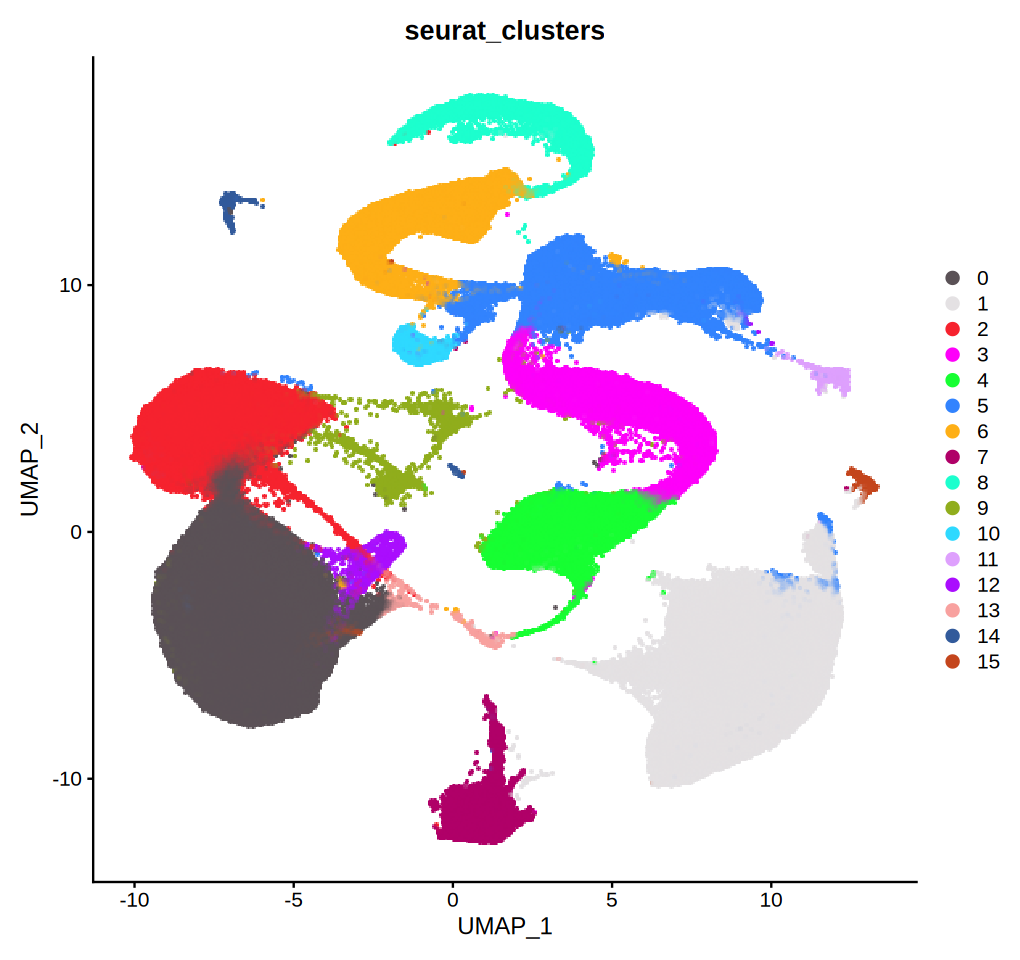

In [12]:
library(scCustomize)
options(repr.plot.height=8,repr.plot.width=8.5)
DimPlot_scCustom(sce1_TME, pt.size=2,reduction = "UMAP", group.by = c("seurat_clusters"),label=F) 

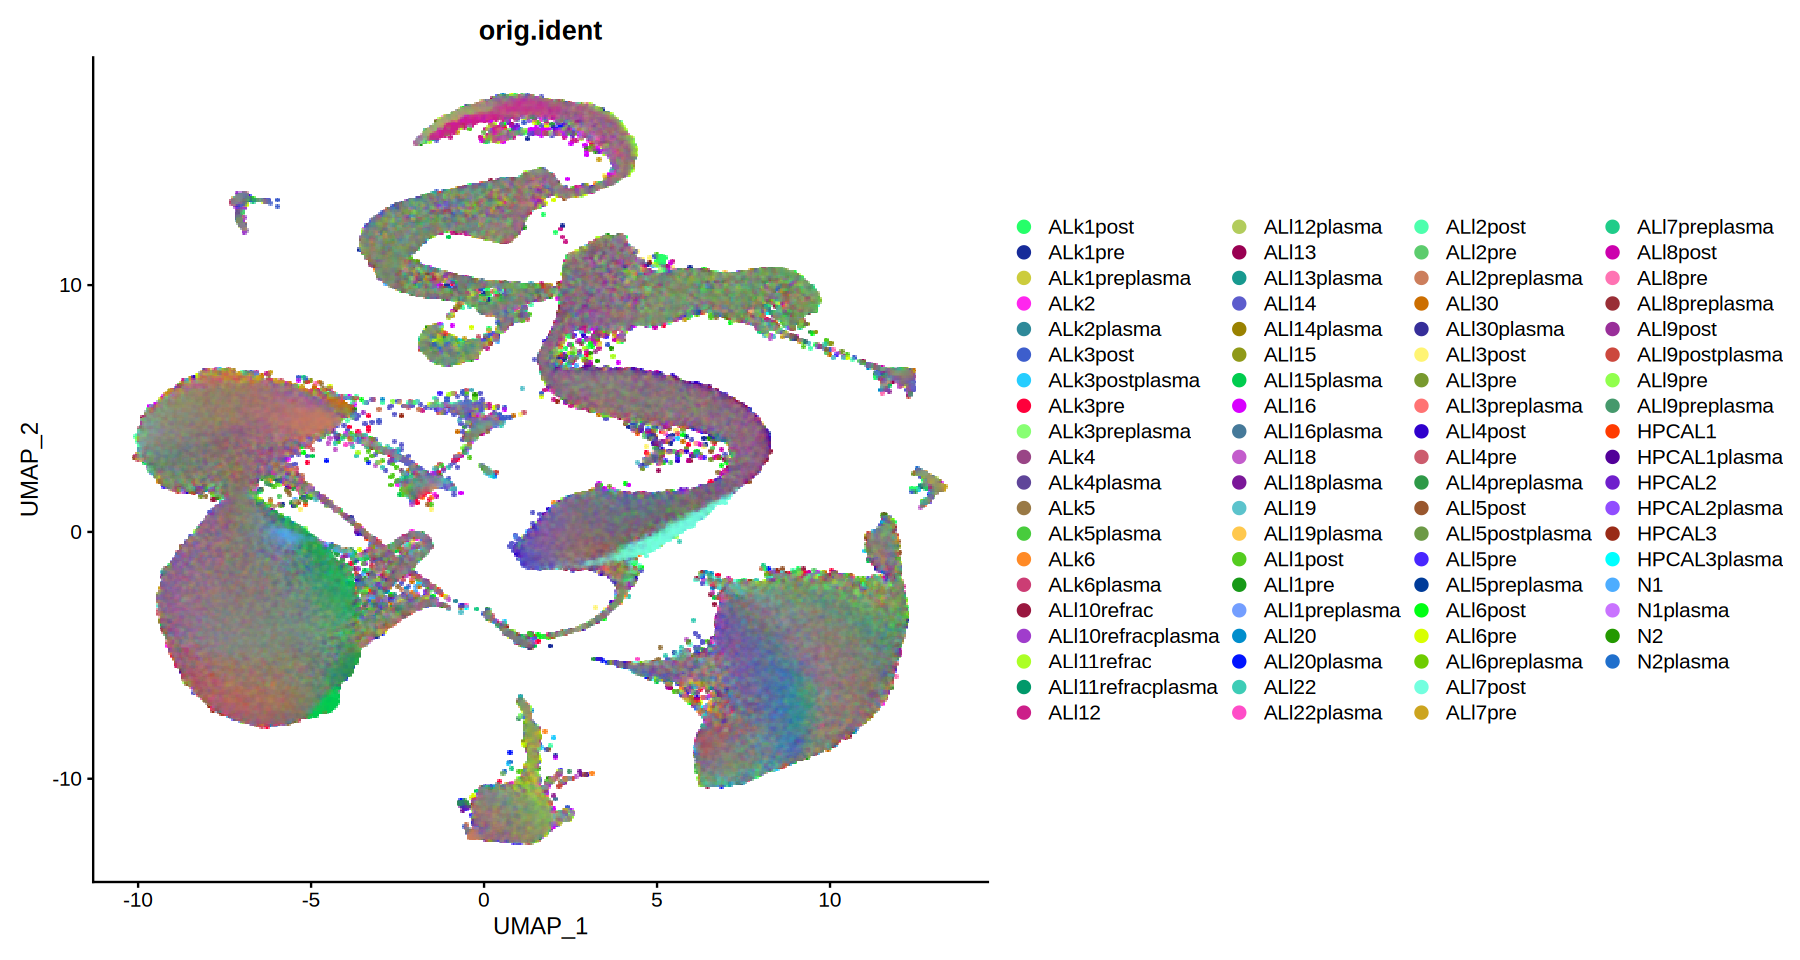

In [13]:
library(scCustomize)
options(repr.plot.height=8,repr.plot.width=15)
DimPlot_scCustom(sce1_TME, pt.size=2,reduction = "UMAP", group.by = c("orig.ident"),label=F) 

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



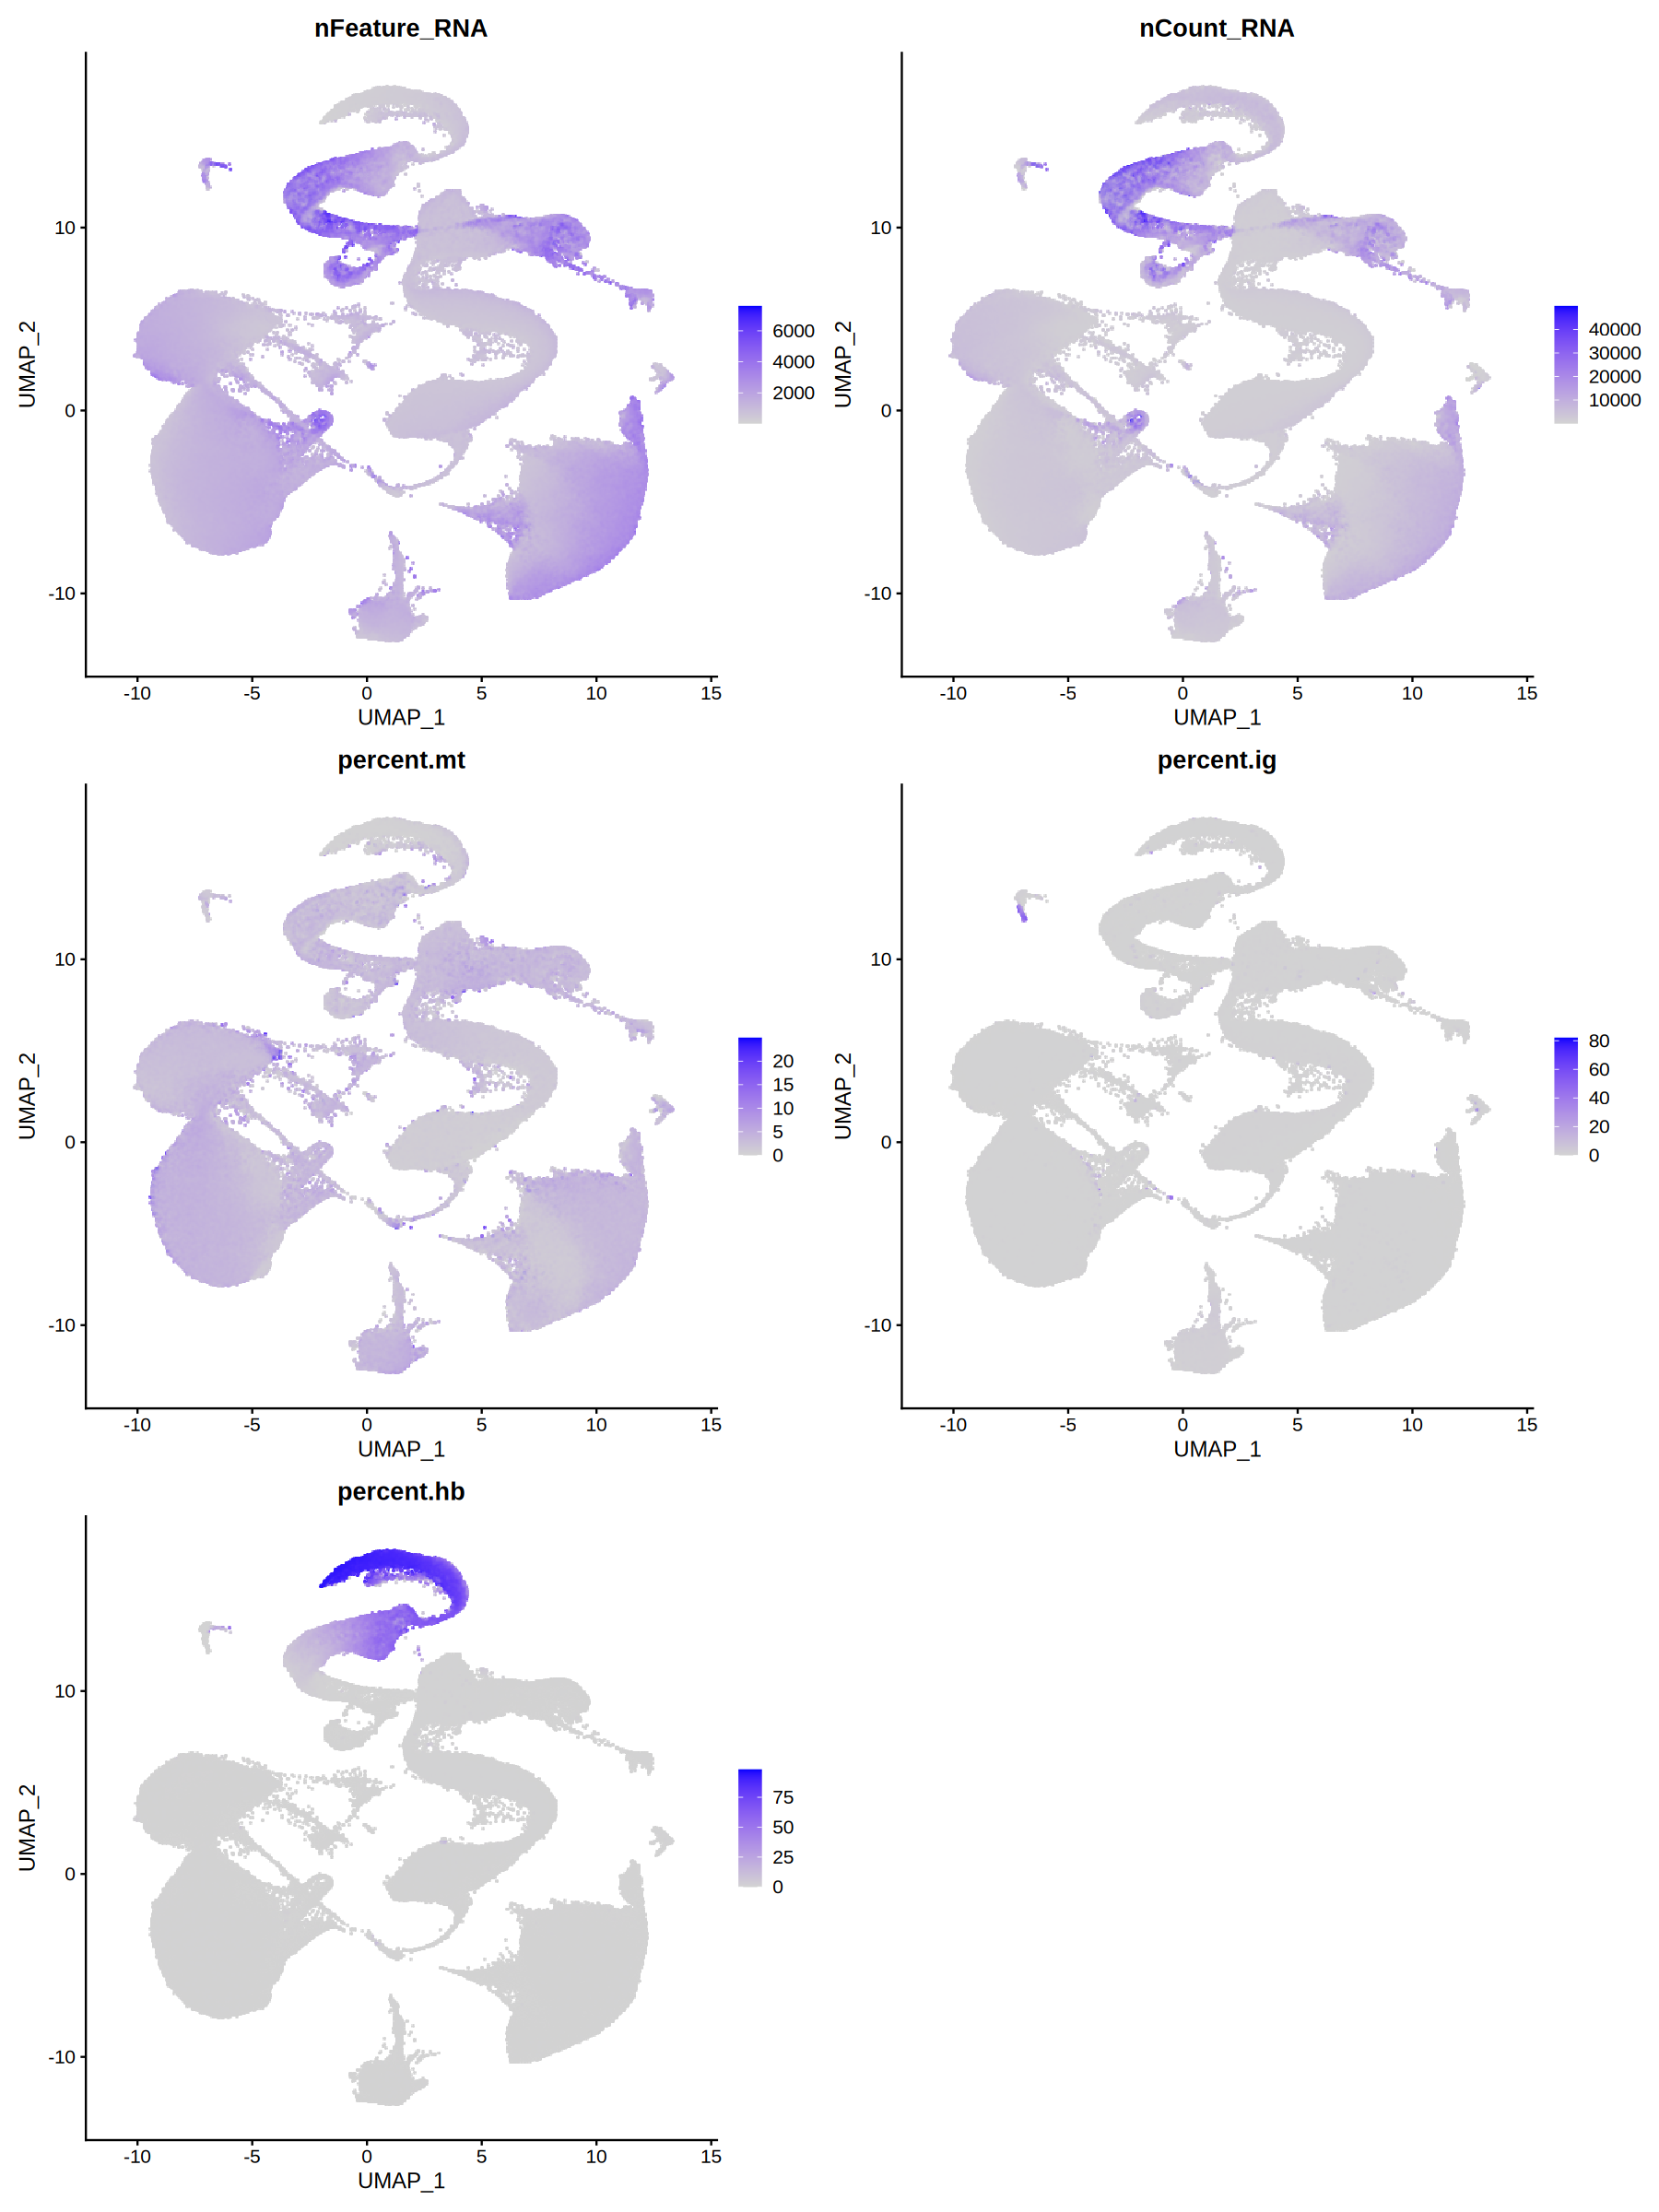

In [14]:
library('RColorBrewer')
options(repr.plot.height=20,repr.plot.width=15)
FeaturePlot(sce1_TME, pt.size=2,reduction = "UMAP", feature = c("nFeature_RNA", "nCount_RNA","percent.mt","percent.ig","percent.hb"),label=F) 

In [15]:
library('SingleR')
Immune.se=DatabaseImmuneCellExpressionData()
Nover.se=NovershternHematopoieticData()
MonacoIm.se=MonacoImmuneData()

see ?celldex and browseVignettes('celldex') for documentation

loading from cache

see ?celldex and browseVignettes('celldex') for documentation

loading from cache

see ?celldex and browseVignettes('celldex') for documentation

loading from cache

see ?celldex and browseVignettes('celldex') for documentation

loading from cache

see ?celldex and browseVignettes('celldex') for documentation

loading from cache

see ?celldex and browseVignettes('celldex') for documentation

loading from cache



In [16]:
# See 'Choices of assay data' for 'assay.type.test=' explanation.
sce1_TME_SingleR <- sceasy::convertFormat(sce1_TME, from="seurat", to="sce")
pred <- SingleR(test = sce1_TME_SingleR , ref = Nover.se, 
    labels = Nover.se$label.fine, assay.type.test=1,check.missing = TRUE)
colnames(pred)

[1] "scores"        "labels"        "delta.next"    "pruned.labels"

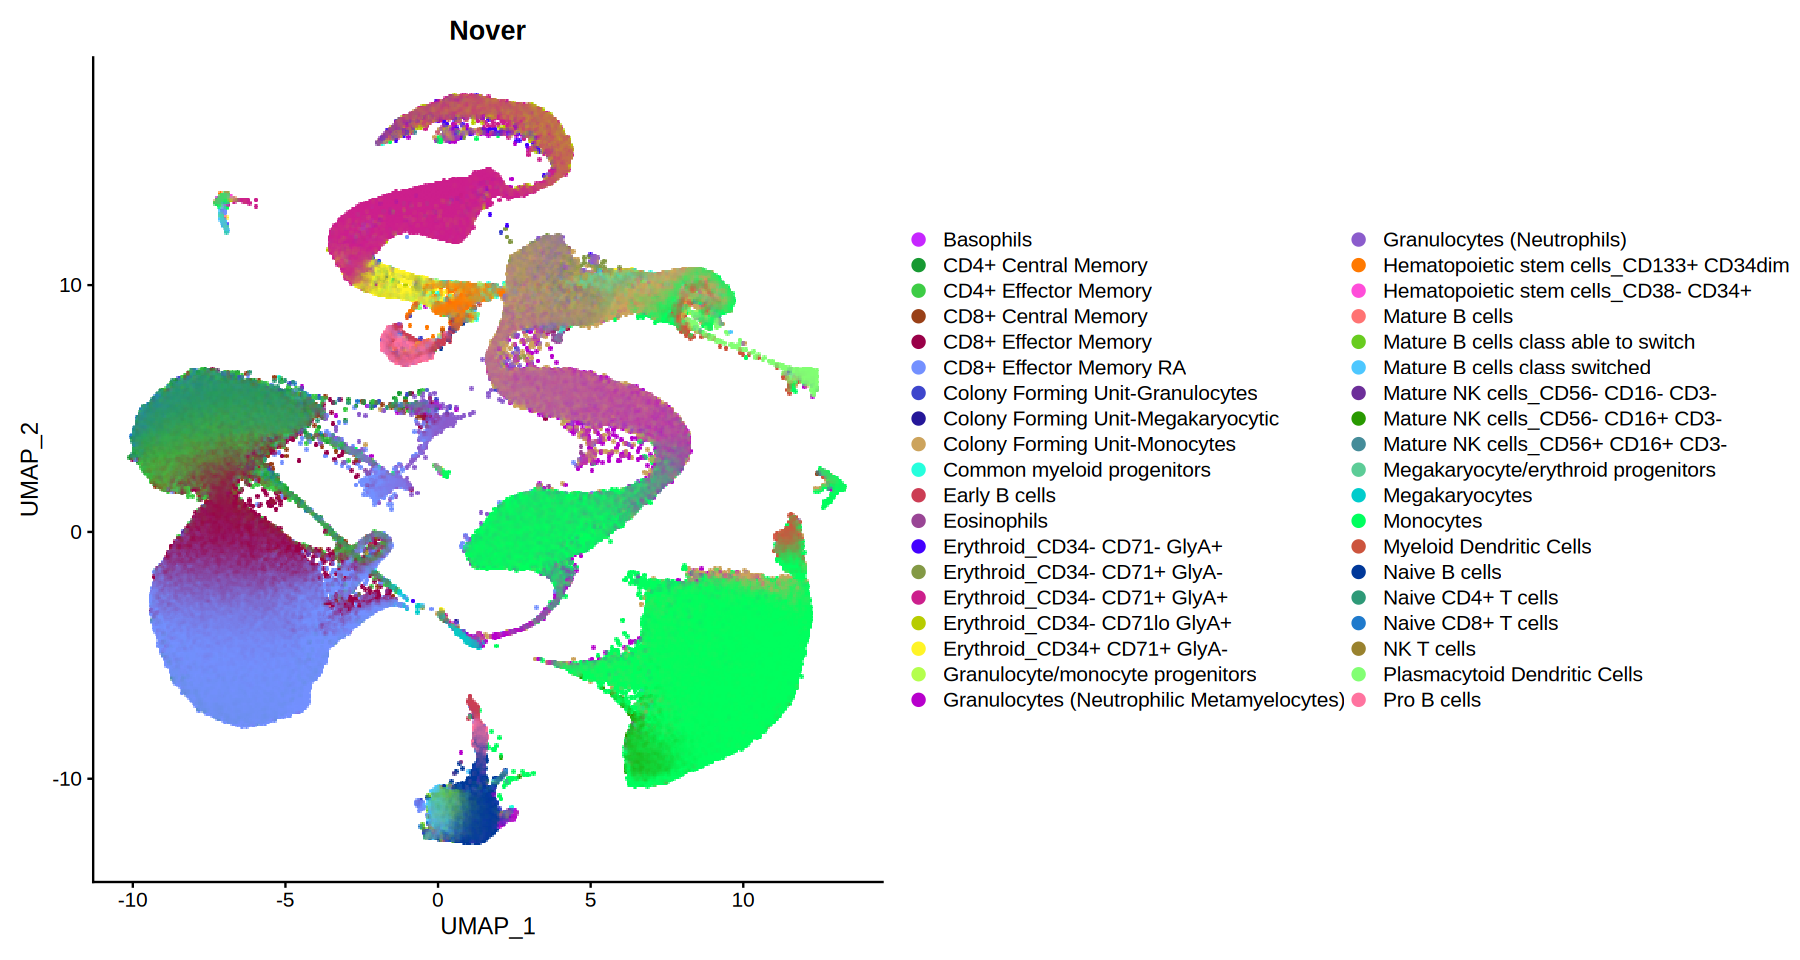

In [17]:
sce1_TME@meta.data$Nover <-pred$labels
options(repr.plot.height=8,repr.plot.width=15)
DimPlot_scCustom(sce1_TME, pt.size=2,reduction = "UMAP", group.by = c("Nover"),label=F) 

In [18]:
saveRDS(sce1_TME, file = "sce1_TME.rds")